In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

rfm = pd.read_csv(r'C:\Users\pench\Documents\ecommerce-segmentation\data\processed\rfm_scores.csv')

print(" RFM data loaded!")
print(f"Shape: {rfm.shape}")
rfm[['CustomerName','Recency','Frequency','Monetary']].head()

 RFM data loaded!
Shape: (332, 10)


,CustomerName,Recency,Frequency,Monetary
0,Aakanksha,274,1,74.0
1,Aarushi,10,3,4701.0
2,Aashna,118,1,1931.0
3,Aastha,157,1,3276.0
4,Aayush,137,1,556.0


In [2]:
# Use only R, F, M values for clustering
X = rfm[['Recency', 'Frequency', 'Monetary']].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(" Features scaled!")
print("Before scaling - Recency mean:", round(X['Recency'].mean(), 2))
print("After scaling  - Recency mean:", round(X_scaled[:,0].mean(), 4))

 Features scaled!
Before scaling - Recency mean: 130.59
After scaling  - Recency mean: -0.0


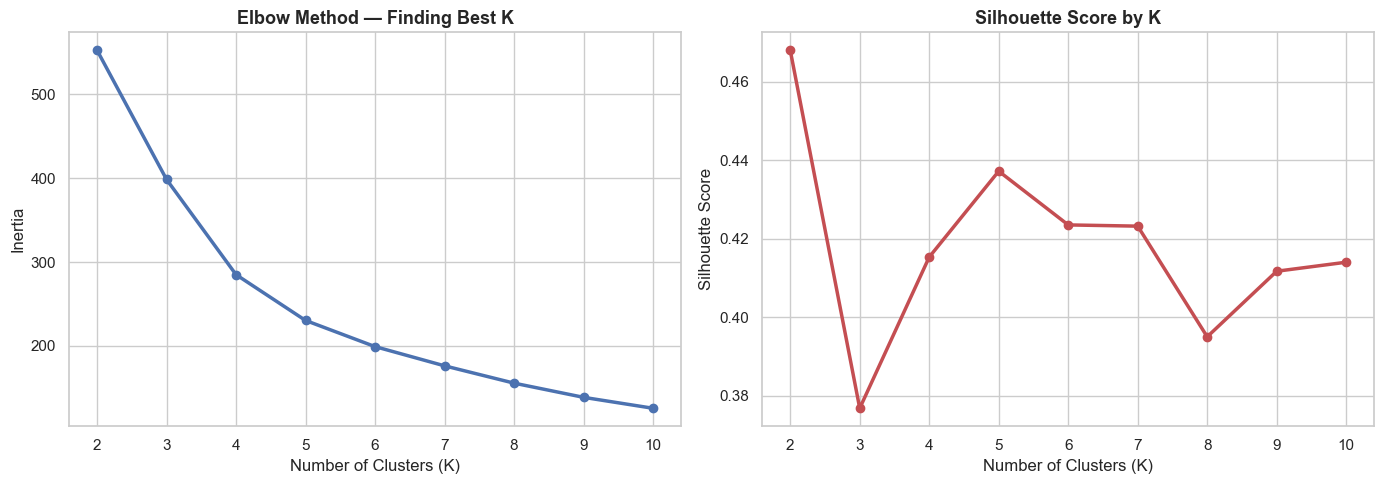

 Elbow curve saved!


In [3]:
inertia = []
silhouette = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, km.labels_))

# Plot Elbow Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertia, 'bo-', linewidth=2.5)
axes[0].set_title('Elbow Method — Finding Best K', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, silhouette, 'ro-', linewidth=2.5)
axes[1].set_title('Silhouette Score by K', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig(r'C:\Users\pench\Documents\ecommerce-segmentation\outputs\07_elbow_curve.png',
            bbox_inches='tight')
plt.show()
print(" Elbow curve saved!")

In [4]:
# K=4 is usually best for customer segmentation
best_k = 4

km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm['Cluster'] = km.fit_predict(X_scaled)

print(f" K-Means trained with K={best_k}")
print("\nCustomers per cluster:")
print(rfm['Cluster'].value_counts().sort_index())
print(f"\nSilhouette Score: {silhouette_score(X_scaled, rfm['Cluster']):.4f}")

 K-Means trained with K=4

Customers per cluster:
Cluster
0     71
1     31
2     88
3    142
Name: count, dtype: int64

Silhouette Score: 0.4153


In [5]:
cluster_summary = rfm.groupby('Cluster').agg(
    Customers  = ('CustomerName', 'count'),
    Avg_Recency   = ('Recency',   'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary  = ('Monetary',  'mean')
).round(2)

print(" Cluster Summary:")
print(cluster_summary)

 Cluster Summary:
         Customers  Avg_Recency  Avg_Frequency  Avg_Monetary
Cluster                                                     
0               71        44.30           2.41       1318.00
1               31        56.45           3.06       5120.71
2               88       253.90           1.05        747.86
3              142       113.51           1.00        798.38


In [9]:
# Based on YOUR cluster summary
cluster_labels = {
    0: 'Recent Active Buyers',
    1: 'High Value Champions',
    2: 'Churned Inactive',
    3: 'At Risk'
}

rfm['Cluster_Label'] = rfm['Cluster'].map(cluster_labels)

print("Cluster Labels Assigned:")
print(rfm['Cluster_Label'].value_counts())
print(" Done!")

Cluster Labels Assigned:
Cluster_Label
At Risk                 142
Churned Inactive         88
Recent Active Buyers     71
High Value Champions     31
Name: count, dtype: int64
 Done!


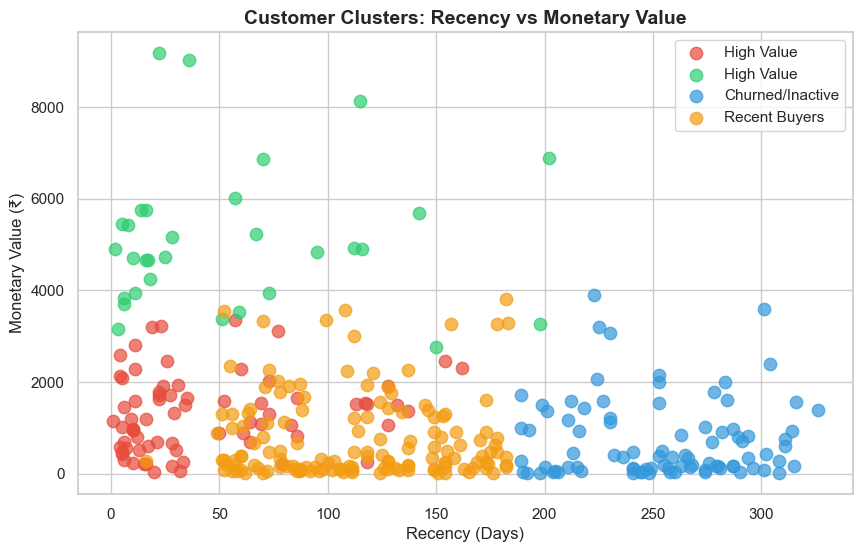

 Plot saved!


In [7]:
colors = ['#e74c3c','#2ecc71','#3498db','#f39c12']
plt.figure(figsize=(10,6))

for i, label in cluster_labels.items():
    mask = rfm['Cluster'] == i
    plt.scatter(rfm[mask]['Recency'], rfm[mask]['Monetary'],
                label=label, color=colors[i], s=80, alpha=0.7)

plt.title('Customer Clusters: Recency vs Monetary Value', fontsize=14, fontweight='bold')
plt.xlabel('Recency (Days)')
plt.ylabel('Monetary Value (₹)')
plt.legend()
plt.savefig(r'C:\Users\pench\Documents\ecommerce-segmentation\outputs\08_cluster_scatter.png',
            bbox_inches='tight')
plt.show()
print(" Plot saved!")

In [8]:
rfm.to_csv(r'C:\Users\pench\Documents\ecommerce-segmentation\data\processed\rfm_clustered.csv',
           index=False)

print(" Final clustered data saved!")
print(f"Columns: {rfm.columns.tolist()}")

 Final clustered data saved!
Columns: ['CustomerName', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Total', 'Segment', 'Cluster', 'Cluster_Label']


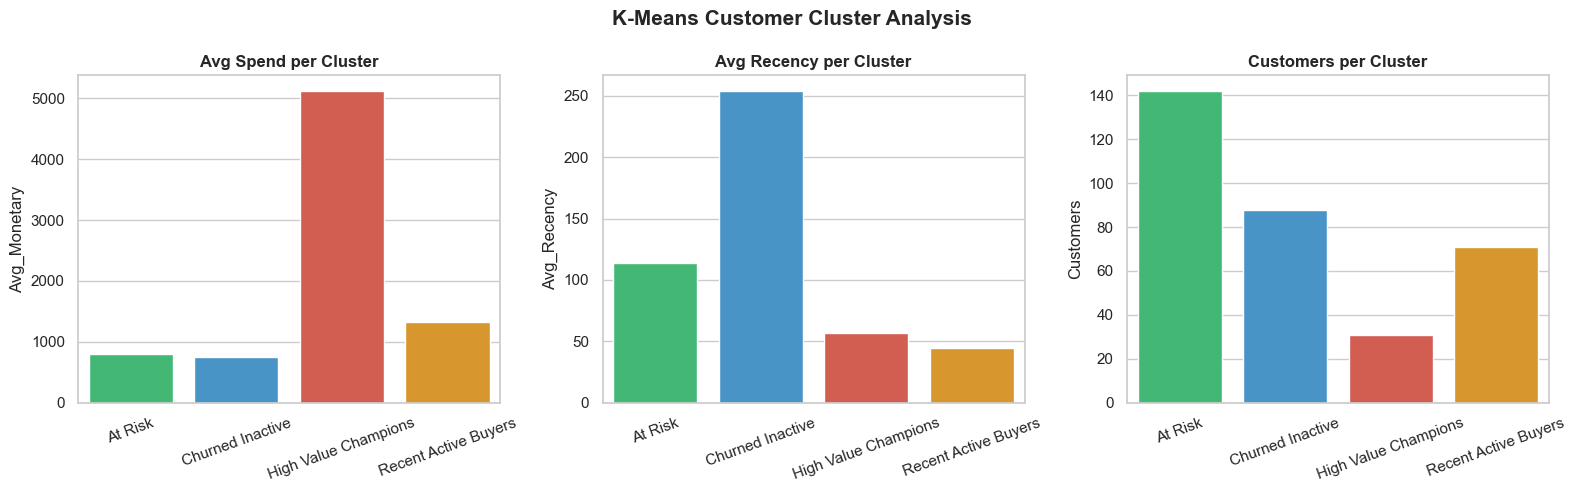

 Plot saved!


In [10]:
cluster_plot = rfm.groupby('Cluster_Label').agg(
    Customers     = ('CustomerName', 'count'),
    Avg_Monetary  = ('Monetary',  'mean'),
    Avg_Recency   = ('Recency',   'mean'),
    Avg_Frequency = ('Frequency', 'mean')
).round(2).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#2ecc71','#3498db','#e74c3c','#f39c12']

# Avg Monetary
sns.barplot(data=cluster_plot, x='Cluster_Label', y='Avg_Monetary',
            hue='Cluster_Label', palette=colors, legend=False, ax=axes[0])
axes[0].set_title('Avg Spend per Cluster', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

# Avg Recency
sns.barplot(data=cluster_plot, x='Cluster_Label', y='Avg_Recency',
            hue='Cluster_Label', palette=colors, legend=False, ax=axes[1])
axes[1].set_title('Avg Recency per Cluster', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)

# Customer Count
sns.barplot(data=cluster_plot, x='Cluster_Label', y='Customers',
            hue='Cluster_Label', palette=colors, legend=False, ax=axes[2])
axes[2].set_title('Customers per Cluster', fontweight='bold')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=20)

plt.suptitle('K-Means Customer Cluster Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\pench\Documents\ecommerce-segmentation\outputs\09_cluster_analysis.png',
            bbox_inches='tight')
plt.show()
print(" Plot saved!")

In [11]:
rfm.to_csv(r'C:\Users\pench\Documents\ecommerce-segmentation\data\processed\rfm_clustered.csv',
           index=False)

# Also save for dashboard
import os
os.makedirs(r'C:\Users\pench\Documents\ecommerce-segmentation\dashboard', exist_ok=True)

rfm.to_csv(r'C:\Users\pench\Documents\ecommerce-segmentation\dashboard\rfm_dashboard.csv',
           index=False)

# Save merged df for dashboard too
df = pd.merge(
    pd.read_csv(r'C:\Users\pench\Documents\ecommerce-segmentation\data\raw\List of Orders.csv'),
    pd.read_csv(r'C:\Users\pench\Documents\ecommerce-segmentation\data\raw\Order Details.csv'),
    on='Order ID'
)
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df.to_csv(r'C:\Users\pench\Documents\ecommerce-segmentation\dashboard\orders_dashboard.csv',
          index=False)

print(" All dashboard files saved!")

 All dashboard files saved!
